In [91]:
import pandas as pd
import numpy as np

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.tools import diff
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

In [62]:
df = pd.read_csv("../data/airline_passengers.csv", index_col="Month", parse_dates=True)
df.index.freq = "MS"

In [63]:
df.shape

(144, 1)

In [64]:
train_data = df.iloc[:109] 
test_data = df.iloc[108:]

In [65]:
fitted_model = ExponentialSmoothing(
    train_data["Thousands of Passengers"],
    trend="mul",
    seasonal="mul",
    seasonal_periods=12 # 12 months per year
    ).fit()

In [66]:
test_preds = fitted_model.forecast(36) # 36 periods prediction into the future
test_preds.head()

1958-02-01    339.143232
1958-03-01    399.281294
1958-04-01    394.232395
1958-05-01    402.543991
1958-06-01    473.128787
Freq: MS, dtype: float64

<Axes: xlabel='Month'>

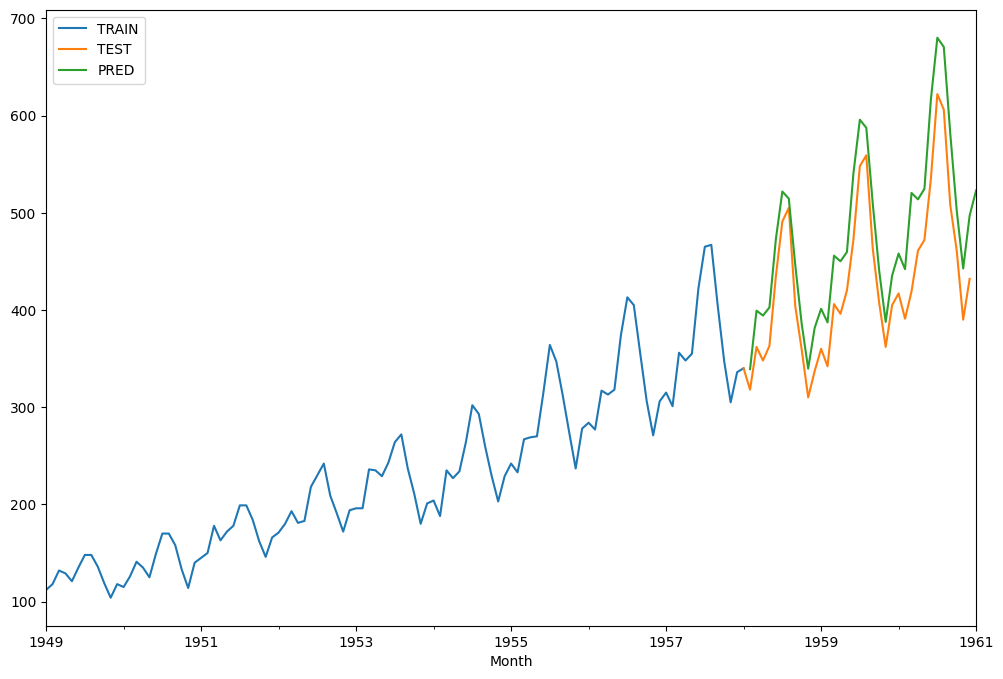

In [67]:
train_data["Thousands of Passengers"].plot(legend=True, label="TRAIN", figsize=(12,8))
test_data["Thousands of Passengers"].plot(legend=True, label="TEST")
test_preds.plot(legend=True, label="PRED")

In [72]:
test_data.describe()

,Thousands of Passengers
count,36.000000
mean,428.500000
std,79.329152
min,310.000000
25%,362.000000
50%,412.000000
75%,472.000000
max,622.000000


In [71]:
mean_absolute_error(test_data, test_preds)

63.03008293411717

In [75]:
root_mean_squared_error(test_data, test_preds)

74.92705699194694

In [ ]:
# for final model to dpeloyment or forecasting into the future we train with all the data
final_model = ExponentialSmoothing(
    df["Thousands of Passengers"],
    trend="mul",
    seasonal="mul",
    seasonal_periods=12
    ).fit()

In [ ]:
forecast_preds = final_model.forecast(36) 

<Axes: xlabel='Month'>

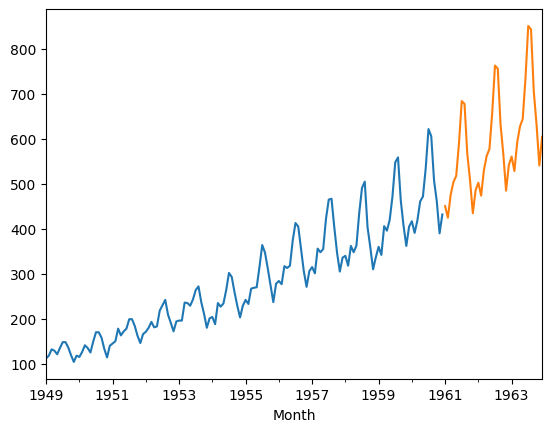

In [ ]:
df["Thousands of Passengers"].plot()
forecast_preds.plot() # predictions into the future, we dont have data to evaluate if they are good or bad

In [83]:
df2 = pd.read_csv("../data/samples.csv", index_col=0, parse_dates=True)
df2.head()

,a,b,c,d
1950-01-01,36,27,0,67
1950-02-01,58,22,3,31
1950-03-01,61,17,5,67
1950-04-01,37,15,8,47
1950-05-01,66,13,8,62


<Axes: >

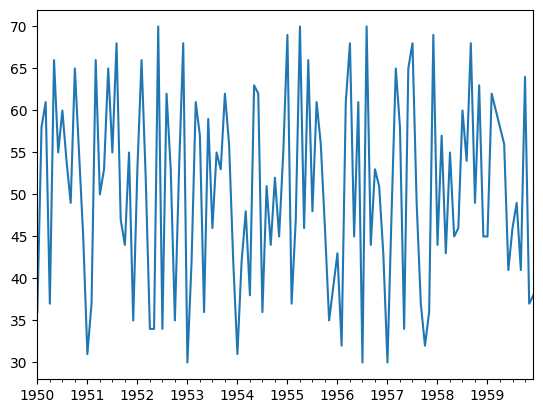

In [ ]:
df2["a"].plot() # stationary data which doesn't exhibit trends or seasonality.

<Axes: >

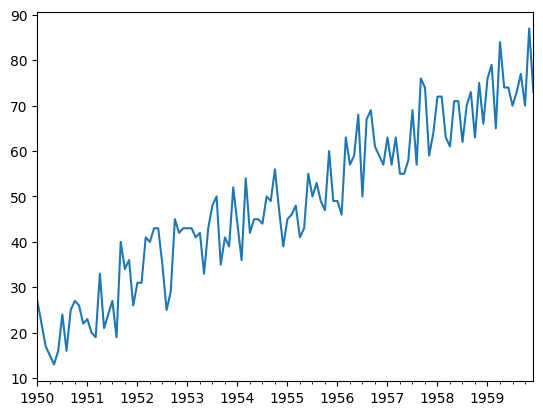

In [88]:
df2["b"].plot() # non-stationary data

In [ ]:
# 3 different ways of creating a derivative function
df2["b"] - df2["b"].shift(1)
df2["b"].diff()
diff(df2["b"], k_diff=1) # from statsmodels library

1950-03-01     0.0
1950-04-01     3.0
1950-05-01     0.0
1950-06-01     5.0
1950-07-01     5.0
              ... 
1959-08-01     7.0
1959-09-01     1.0
1959-10-01   -11.0
1959-11-01    24.0
1959-12-01   -31.0
Name: b, Length: 118, dtype: float64

<Axes: >

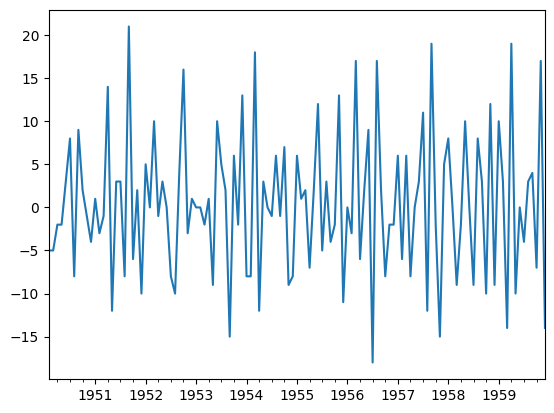

In [ ]:
diff(df2["b"], k_diff=1).plot() # we have removed the seasonality/trend, and create a stationary data